## Let's mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!uv pip install kaggle

Using Python 3.12.13 environment at: /usr
Checked 1 package in 279ms


In [ ]:
from google.colab import userdata
token = userdata.get('kaggle_toke')

In [ ]:
!kaggle datasets download -d potamitis/wingbeats

Dataset URL: https://www.kaggle.com/datasets/potamitis/wingbeats
License(s): CC0-1.0
100% 3.95G/3.95G [00:41<00:00, 101MB/s]



In [ ]:
!unzip -q wingbeats.zip -d wingbeats

replace wingbeats/Wingbeats/Ae. aegypti/D_16_12_12_19_46_13/F161212_194613_156_G_050.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace wingbeats/Wingbeats/Ae. aegypti/D_16_12_12_19_46_13/F161212_194614_157_G_050.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace wingbeats/Wingbeats/Ae. aegypti/D_16_12_12_19_46_13/F161212_194615_158_G_050.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

print(os.listdir("wingbeats")[:10])

['Wingbeats']


## Refine Species and Inspect Audio

### Subtask:
Filter the species list to exclude non-species folders and inspect the properties of a sample audio file.


**Reasoning**:
I will now refine the species list by excluding the redundant 'Wingbeats' folder and then use librosa to inspect a sample audio file to confirm data integrity and properties like sample rate and duration.



In [ ]:
import librosa
import os

# 1. Filter the species list
valid_species = [s for s in species if s != 'Wingbeats']
print(f"Refined Species List: {valid_species}")

# 2. Pick a sample file for inspection
# Using An. arabiensis as it was the last one explored
sample_species = 'An. arabiensis'
sample_species_path = os.path.join(base_path, sample_species)
sample_subdirs = [d for d in os.listdir(sample_species_path) if os.path.isdir(os.path.join(sample_species_path, d))]

if sample_subdirs:
    first_subdir = os.path.join(sample_species_path, sample_subdirs[0])
    sample_files = [f for f in os.listdir(first_subdir) if f.endswith('.wav')]

    if sample_files:
        sample_file_path = os.path.join(first_subdir, sample_files[0])
        print(f"\nInspecting file: {sample_file_path}")

        # Load audio properties
        y, sr = librosa.load(sample_file_path, sr=None)
        duration = librosa.get_duration(y=y, sr=sr)

        print(f"Sample Rate: {sr} Hz")
        print(f"Duration: {duration:.4f} seconds")
        print(f"Number of Samples: {len(y)}")
    else:
        print("No .wav files found in the sample subdirectory.")
else:
    print("No subdirectories found for the sample species.")

Refined Species List: ['An. gambiae', 'C. pipiens', 'An. arabiensis', 'C. quinquefasciatus', 'Ae. aegypti', 'Ae. albopictus']

Inspecting file: wingbeats/Wingbeats/An. arabiensis/D_17_02_04_00_01_13/F170204_022318_024_G_050.wav
Sample Rate: 8000 Hz
Duration: 0.6250 seconds
Number of Samples: 5000


## Build Metadata DataFrame

### Subtask:
Recursively iterate through all species folders (excluding 'Wingbeats'), capturing every .wav file path, its corresponding label, and its sub-directory ID into a pandas DataFrame.

In [ ]:
import pandas as pd
import os

data_records = []

# We use the valid_species list defined previously
for species_name in valid_species:
    species_dir = os.path.join(base_path, species_name)

    # Walk through the species directory to find all .wav files in subdirectories
    for root, dirs, files in os.walk(species_dir):
        for file in files:
            if file.endswith('.wav'):
                # Construct the full path
                full_path = os.path.join(root, file)
                # Extract the sub-folder (session ID)
                sub_folder = os.path.basename(root)

                data_records.append({
                    'file_path': full_path,
                    'label': species_name,
                    'sub_folder': sub_folder
                })

# Create the DataFrame
metadata_df = pd.DataFrame(data_records)

print(f"Total audio files found: {len(metadata_df)}")
display(metadata_df.head())

# Verify the count per species
print("\nSamples per species:")
display(metadata_df['label'].value_counts())

Total audio files found: 279566


,file_path,label,sub_folder
0,wingbeats/Wingbeats/An. gambiae/Anopheles gamb...,An. gambiae,D_17_01_17_15_21_49
1,wingbeats/Wingbeats/An. gambiae/Anopheles gamb...,An. gambiae,D_17_01_17_15_21_49
2,wingbeats/Wingbeats/An. gambiae/Anopheles gamb...,An. gambiae,D_17_01_17_15_21_49
3,wingbeats/Wingbeats/An. gambiae/Anopheles gamb...,An. gambiae,D_17_01_17_15_21_49
4,wingbeats/Wingbeats/An. gambiae/Anopheles gamb...,An. gambiae,D_17_01_17_15_21_49



Samples per species:


,count
label,
Ae. aegypti,85553
C. quinquefasciatus,74599
An. gambiae,49471
C. pipiens,30415
Ae. albopictus,20231
An. arabiensis,19297


## Validate Distribution

### Subtask:
Visualize the distribution of audio samples across the 6 insect species to identify any data imbalances.

/tmp/ipykernel_500/3307155417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=metadata_df, x='label', order=metadata_df['label'].value_counts().index, palette='viridis')


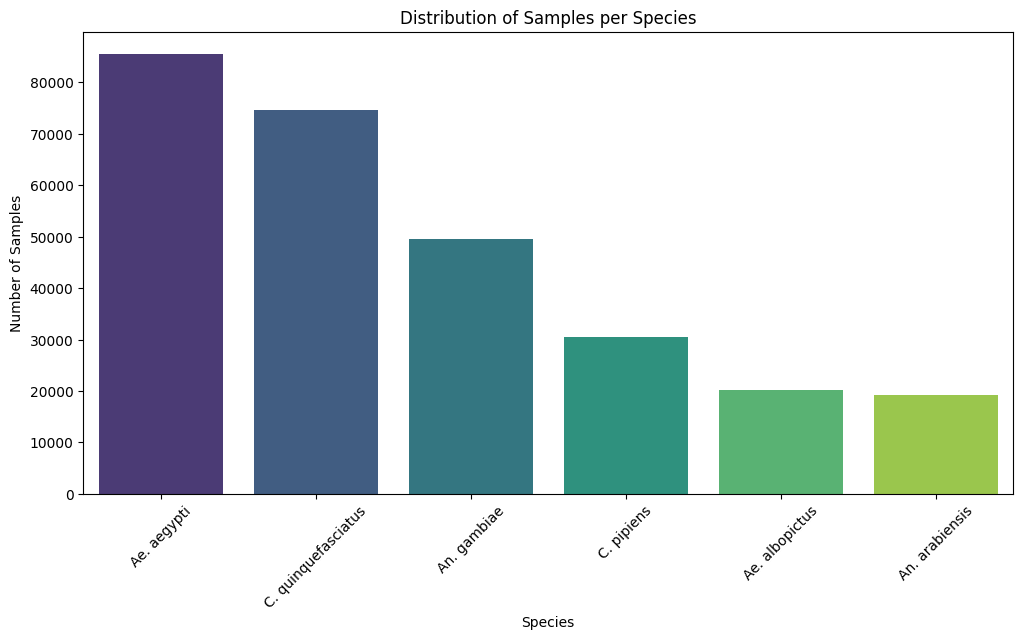

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=metadata_df, x='label', order=metadata_df['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Samples per Species')
plt.xlabel('Species')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

## Export for Hugging Face

### Subtask:
Save the final cleaned metadata to a CSV file named 'metadata.csv', ensuring compatibility with the Hugging Face Datasets 'Audio' feature.

In [ ]:
# 1. Adjust paths to be relative to the 'wingbeats' root for Hugging Face compatibility
# Currently, they include 'wingbeats/Wingbeats/...'.
# Hugging Face usually expects paths relative to the dataset root.
hf_metadata = metadata_df.copy()
hf_metadata['file_path'] = hf_metadata['file_path'].apply(lambda x: os.path.relpath(x, start='wingbeats'))

# 2. Rename columns to standard HF names if preferred (optional, but 'file_name' is standard)
hf_metadata = hf_metadata.rename(columns={'file_path': 'file_name'})

# 3. Export to CSV
csv_path = 'wingbeats/metadata.csv'
hf_metadata.to_csv(csv_path, index=False)

print(f"Metadata exported successfully to {csv_path}")
print(f"Final column schema: {list(hf_metadata.columns)}")
print(f"Total rows: {len(hf_metadata)}")
display(hf_metadata.head())

Metadata exported successfully to wingbeats/metadata.csv
Final column schema: ['file_name', 'label', 'sub_folder']
Total rows: 279566


,file_name,label,sub_folder
0,Wingbeats/An. gambiae/Anopheles gambiae_ 5d-7d...,An. gambiae,D_17_01_17_15_21_49
1,Wingbeats/An. gambiae/Anopheles gambiae_ 5d-7d...,An. gambiae,D_17_01_17_15_21_49
2,Wingbeats/An. gambiae/Anopheles gambiae_ 5d-7d...,An. gambiae,D_17_01_17_15_21_49
3,Wingbeats/An. gambiae/Anopheles gambiae_ 5d-7d...,An. gambiae,D_17_01_17_15_21_49
4,Wingbeats/An. gambiae/Anopheles gambiae_ 5d-7d...,An. gambiae,D_17_01_17_15_21_49


### Push to Hugging Face Hub
We will now load the local folder as a dataset and push it to your Hugging Face account. Ensure you have your `HF_TOKEN` set in Colab secrets.

In [ ]:
!pip install -q datasets huggingface_hub

In [ ]:
!hf auth login

Hint: A new version of huggingface_hub (1.27.0) is available! You are using version 1.23.0.
To update, run: hf update
? How would you like to log in?  [Use arrows, Enter to confirm]
> Log in with your browser
  Paste an access token
? How would you like to log in? Log in with your browser

    Open this URL in your browser:
        https://hf.co/oauth/device

    And enter the code: P2HQ-KQMX

    Waiting for authorization...P2HQ-KQMX
.....
Token is valid.
The token `oauth-BigTrev89` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `oauth-BigTrev89`
Note: This token will be refreshed automatically when it expires.


In [ ]:
from datasets import Dataset, Audio
import os

# 1. Create a Hugging Face Dataset directly from your existing DataFrame

metadata_for_hf = hf_metadata.copy()
metadata_for_hf['file_name'] = metadata_for_hf['file_name'].apply(lambda x: os.path.join('wingbeats', x))

dataset = Dataset.from_pandas(metadata_for_hf)

# 2. Cast the 'file_name' column to the Audio feature
dataset = dataset.cast_column("file_name", Audio())

# 3. Push to Hub
repo_id = "BigTrev89/wingbeats-insect-audio"
dataset.push_to_hub(repo_id)

print(f"Dataset successfully pushed to: https://huggingface.co/datasets/{repo_id}")

Uploading the dataset shards:   0%|          | 0/6 [00:00<?, ? shards/s]

Map:   0%|          | 0/46595 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/466 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/466 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   0%|          |  639kB /  467MB            

Dataset successfully pushed to: https://huggingface.co/datasets/BigTrev89/wingbeats-insect-audio
